# Тензорный считыватель
```pip install numpy```

Для геолина **меняем местами индексы** *суперстроки* и *суперстолбца*:
```[a][b][c][d][e] -> [a][b][d][c][e]```

В классе Tensor это условие учтено, в остальном - нужно следить **самостоятельно**!

In [2]:
import numpy as np
import itertools as it
from math import *
from enum import Enum

class TStatus(Enum):
    EVEN = 0
    VERTICAL = 1
    HORIZONTAL = 2

class Tensor:
    t: list
    dim: int
    covector: int
    vector: int
    deep: int
    status: TStatus
    
    def __init__(self, s, dim: int, covector: int, vector: int, status: TStatus = None, a_type=int):
        # Check dimensions and indexes
        if covector + vector <= 0:
            raise ValueError('ERR: 0 indexes for vectors or covectors')
            
        # Set dimensions
        self.dim = dim
        self.covector, self.vector = covector, vector
        self.deep = covector + vector
        
        # Check status
        if self.deep % 2:
            if status is not None and status != TStatus.EVEN:
                self.status = status
            else:
                self.status = (TStatus.VERTICAL if self.vector == 0 else TStatus.HORIZONTAL)
        else:
            self.status = TStatus.EVEN
        
        if isinstance(s, str):
            # Clear string data
            s = s.replace('−', '-').replace('\u200b', '').split()
            # Empty t
            self.t = np.zeros([self.dim] * self.deep, a_type)
            
            if self.status is TStatus.HORIZONTAL:
                divisors = [ind // 2 + (self.deep // 2 if ind % 2 else 0) for ind in range(self.deep - 1)] + [self.deep - 1]
            else:
                divisors = [ind // 2 + (self.deep // 2 + self.deep % 2 if ind % 2 else 0) for ind in range(self.deep)]
                
            for m in range(len(s)):
                index = [m // (self.dim ** div) % self.dim for div in divisors]
                self.t[*index] = s[m]
                # print(m + 1, '=', ', '.join(str(x + 1) for x in index), '=', s[m])
        elif isinstance(s, (np.ndarray, np.generic)):
            self.t = s
        else:
            self.t = np.zeros([self.dim] * self.deep, a_type)

    def _iterate_show(self):
        """Переборный интератор для show
        ИНДЕКСАЦИЯ: строка - столбец - суперстрока - суперстолбец - гиперстрока - гиперстолбец -
        """
        axes = list(range(self.deep - 1, -1, -1))
        if self.status is TStatus.HORIZONTAL:
            order = [ax for ax in axes if ax % 2 == 0 and ax != axes[0]] + [axes[0]] + [ax for ax in axes if ax % 2 != 0]
        else:
            order = [ax for ax in axes if ax % 2 == 0] + [ax for ax in axes if ax % 2 != 0]
        # print(axes, order)
        for indices in it.product(range(self.dim), repeat=self.deep):
            original_indices = [0] * self.deep
            for original_axis in range(self.deep):
                pos = order.index(original_axis)
                original_indices[original_axis] = indices[pos]
            yield tuple(original_indices)

    
    def show(self, sym_element=' ', sym_line='\n', sym_superline='\n\n', sym_superraw=' | ') -> str:
        """Превращает тензор в текст для вывода:
            sym_element: между двумя элементами, sym_line: перенос каждую строку,
            sym_superline: перенос каждую суперстроку, sym_superraw: перенос каждый суперстолбец.
        
        ИНДЕКСАЦИЯ: строка - столбец - суперстрока - суперстолбец - гиперстрока - гиперстолбец -
        """
        s = ''
        pre_line, pre_superline, pre_superraw = 0, 0, 0
        for indices in self._iterate_show():
            if len(indices) == 1:
                if (pre_line != indices[0]) and (self.status is TStatus.VERTICAL):
                    s += sym_line
                elif indices[0] != 0:
                    s += sym_element
                pre_line = indices[0]
            elif len(indices) == 2:
                if (pre_line != indices[0]):
                    s += sym_line
                elif indices[0] != 0 or indices[1] != 0:
                    s += sym_element
                pre_line = indices[0]
            elif len(indices) == 3:
                if self.status is TStatus.HORIZONTAL:
                    if (pre_line != indices[0]):
                        s += sym_line
                    elif (pre_superraw != indices[2]):
                        s += sym_superraw
                    elif indices[0] != 0 or indices[1] != 0:
                        s += sym_element
                    pre_line, pre_superraw = indices[0], indices[2]
                else:
                    if (pre_line != indices[0]):
                        s += sym_line
                    elif (pre_superline != indices[2]):
                        s += sym_superline
                    elif indices[0] != 0 or indices[1] != 0:
                        s += sym_element
                    pre_line, pre_superline = indices[0], indices[2]
            else:
                if (pre_line != indices[0]):
                    s += sym_line
                elif (pre_superline != indices[2]):
                        s += sym_superline
                elif (pre_superraw != indices[3]):
                    s += sym_superraw
                elif not all(i == 0 for i in indices):
                    s += sym_element
                pre_line, pre_superline, pre_superraw = indices[0], indices[2], indices[3]
            # print(indices)
            s += str(self.t[indices])
        return s
    
    @property
    def format(self):
        return '[' + self.show(', ', '; ', ', ', ', ') +']'
    
    def __getitem__(self, prop):
        return self.t[prop]
    
    def __setitem__(self, key, value):
        self.t[key] = value
    
    def __str__(self):
        return f'Tensor ({self.vector}, {self.covector}), dim = {self.dim}, status = {self.status}\n' + self.show() + '\n' + self.format
    
    def __repr__(self):
        return f'Tensor ({self.vector}, {self.covector})'
    
    def __mul__(self, other):
        return Tensor(other * self.t, self.dim, self.covector, self.vector, self.status)
    
    def __add__(self, other):
        return Tensor(self.t + other.t, self.dim, self.covector, self.vector, self.status)
    
    def __sub__(self, other):
        return Tensor(self.t - other.t, self.dim, self.covector, self.vector, self.status)
    
    @staticmethod
    def fuck_geolin(indices, COB):
        indices = list(indices)
        if len(indices) <= 3:
            return indices
        start = 2  # Начало подсписка для обработки
        if len(indices) % 2:
            # Нечётная длина: обрабатываем элементы со 2 до предпоследнего
            sub_len = len(indices) - 3  # Длина подсписка indices[2:-1]
            processed = [indices[start + i + 1] if i % 2 == 0 else indices[start + i - 1] for i in range(sub_len)]
            return indices[:2] + processed + [indices[-1]]
        else:
            # Чётная длина: обрабатываем все элементы с индекса 2
            sub_len = len(indices) - start
            processed = [indices[start + i + 1] if i % 2 == 0 else indices[start + i - 1] for i in range(sub_len)]
            return indices[:2] + processed
    
    def __matmul__(A, B):
        dim = A.dim
        out = Tensor(0, dim, A.covector + B.covector, A.vector + B.vector, a_type=A.t.dtype)
        for COindicesA in it.product(range(dim), repeat=A.covector):
            for COindicesB in it.product(range(dim), repeat=B.covector):
                for indicesA in it.product(range(dim), repeat=A.vector):
                    for indicesB in it.product(range(dim), repeat=B.vector):
                        indices = Tensor.fuck_geolin(COindicesA + COindicesB + indicesA + indicesB, COindicesB)
                        out[*indices] = A[*(COindicesA+indicesA)] * B[*(COindicesB+indicesB)]     
        return out
        
tens = [
    Tensor('1 2', 2, 1, 0),
    Tensor('1 2', 2, 0, 1),
    Tensor('1 2 3 4', 2, 1, 1),
    Tensor('1 2 3 4 5 6 7 8', 2, 3, 0),
    Tensor('1 2 3 4 5 6 7 8', 2, 0, 3),
    Tensor('1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16', 2, 2, 2),
    Tensor(' '.join(str(x) for x in range(1, 32 + 1)), 2, 5, 0),
    Tensor(' '.join(str(x) for x in range(1, 32 + 1)), 2, 3, 2)
]
# [print('========== ', ten.status, '\n', ten, sep='') for ten in tens[:]]
    

# Задачи

### Задача 1
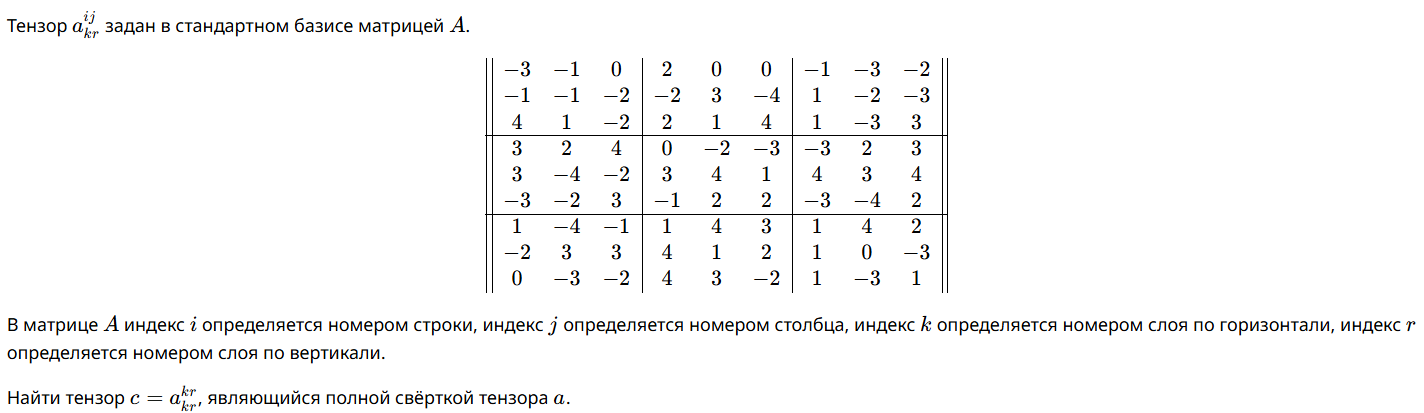

Для геолина **меняем местами индексы** *суперстроки* и *суперстолбца*

In [3]:
# i строка, j столбец, k суперстолбец, r суперстрока
data = """
−3 −1 4 3 3 −3 1 −2 0 ​ −1 −1 1 2 −4 −2 −4 3 −3 ​ 0 −2 −2 4 −2 3 −1 3 −2 ​ 2 −2 2 0 3 −1 1 4 4 ​ 0 3 1 −2 4 2 4 1 3 ​ 0 −4 4 −3 1 2 3 2 −2 ​ −1 1 1 −3 4 −3 1 1 1 ​ −3 −2 −3 2 3 −4 4 0 −3 ​ −2 −3 3 3 4 2 2 −3 1 ​ ​ ​​
"""
tensor = Tensor(data, 3, 2, 2)
# print('A', tensor)
s = 0
for k in range(3):
    for r in range(3):
        # print(k + 1, r + 1, k + 1, r + 1, 'is', tensor[k][r][r][k])
        s += tensor[k][r][r][k]

print(f'[{s}]')

[0]


### Задача 2

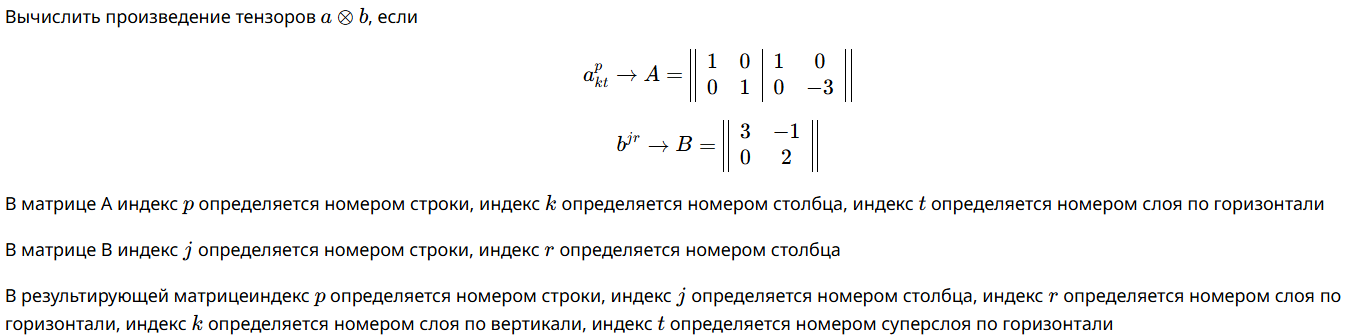

In [4]:
# p строка, k столбец, t суперстолбец
tensor2A = Tensor('1 0 0 1 1 0 0 -3', 2, 1, 2)
# j строка, r столбец
tensor2B = Tensor('3 0 -1 2', 2, 2, 0)
# print('A', tensor2A)
# print('B', tensor2B)
res = tensor2A @ tensor2B
print('RES', res)

RES Tensor (2, 3), dim = 2, status = TStatus.HORIZONTAL
3 0 | -1 2 | 3 0 | -1 2
0 0 | 0 0 | 0 0 | 0 0
0 0 | 0 0 | 0 0 | 0 0
3 0 | -1 2 | -9 0 | 3 -6
[3, 0, -1, 2, 3, 0, -1, 2; 0, 0, 0, 0, 0, 0, 0, 0; 0, 0, 0, 0, 0, 0, 0, 0; 3, 0, -1, 2, -9, 0, 3, -6]


### Задача 3

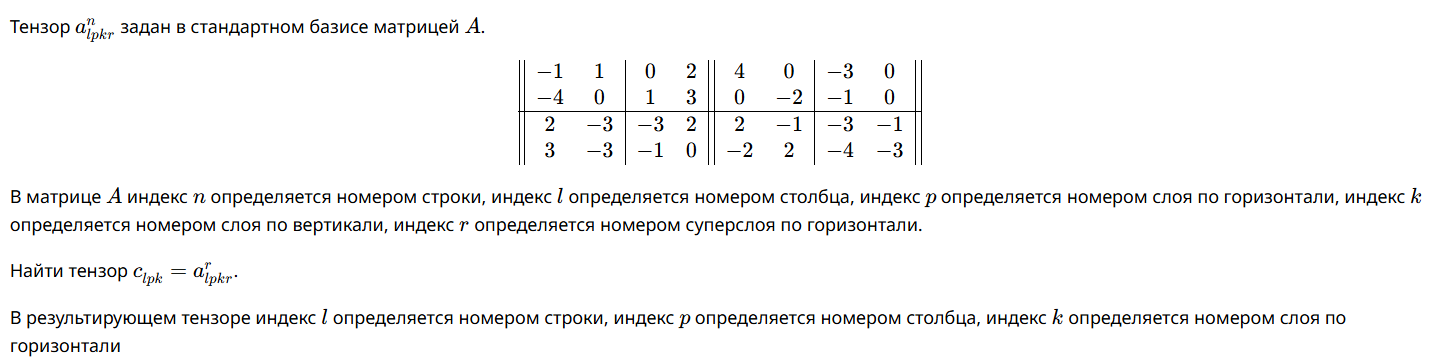

Для геолина **меняем местами индексы** *суперстроки* и *суперстолбца*

In [5]:
data = '''
−1 −4 2 3 ​ 1 0 −3 −3 ​ 0 1 −3 −1 ​ 2 3 2 0 ​ 4 0 2 −2 ​ 0 −2 −1 2 ​ −3 −1 −3 −4 ​ 0 0 −1 −3 ​ ​ ​
'''
A = Tensor(data, 2, 1, 4)
print(A)
C = Tensor(0, 2, 0, 3)
for l, p, k, r in it.product(range(2), repeat=4):
    # swap СУПЕРСТРОКА - СУПЕРСТОЛБЕЦ
    C[l][p][k] += A[r][l][k][p][r]
                
print(C)

Tensor (4, 1), dim = 2, status = TStatus.HORIZONTAL
-1 1 | 0 2 | 4 0 | -3 0
-4 0 | 1 3 | 0 -2 | -1 0
2 -3 | -3 2 | 2 -1 | -3 -1
3 -3 | -1 0 | -2 2 | -4 -3
[-1, 1, 0, 2, 4, 0, -3, 0; -4, 0, 1, 3, 0, -2, -1, 0; 2, -3, -3, 2, 2, -1, -3, -1; 3, -3, -1, 0, -2, 2, -4, -3]
Tensor (3, 0), dim = 2, status = TStatus.HORIZONTAL
-1 -1 | 0 -7
-1 2 | -1 -1
[-1, -1, 0, -7; -1, 2, -1, -1]


### Задача 4

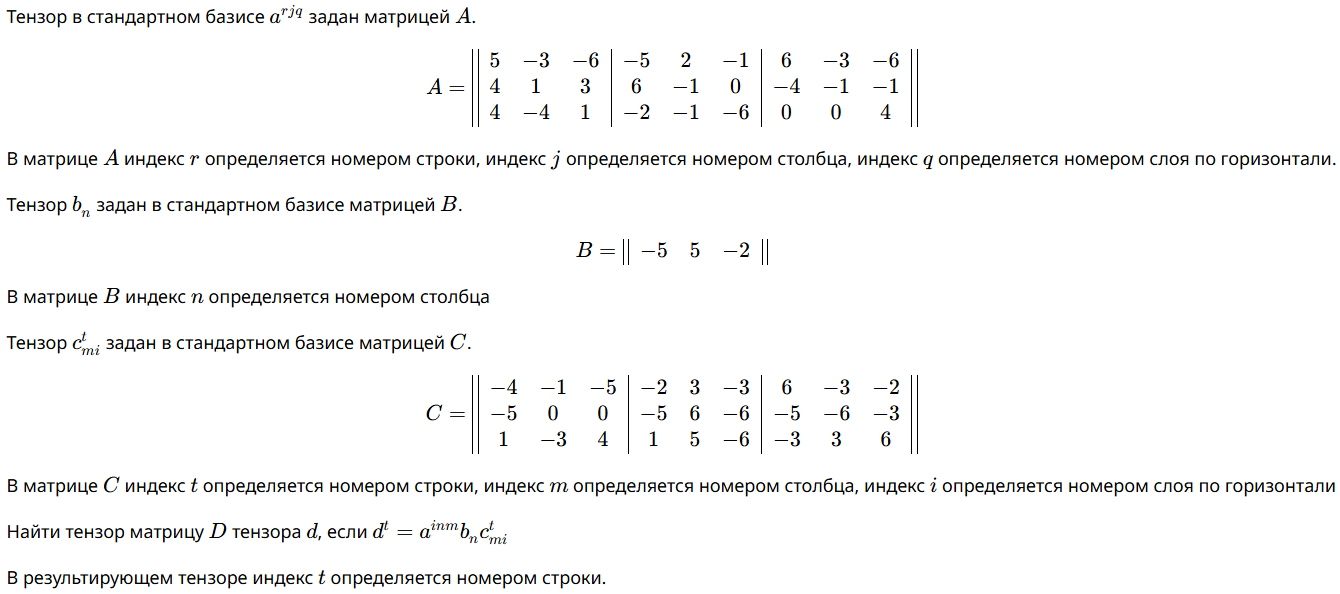

Не забываем про количество **for** для переменных!

Не забываем про **гориз/верт** расположение тензора D: `TStatus`

In [6]:
dataA = '5 4 4 ​ −3 1 −4 ​ −6 3 1 ​ −5 6 −2 ​ 2 −1 −1 ​ −1 0 −6 ​ 6 −4 0 ​ −3 −1 0 ​ −6 −1 4 ​ ​'
dataB = '−5 ​ 5 ​ −2'
dataC = '−4 −5 1 ​ −1 0 −3 ​ −5 0 4 ​ −2 −5 1 ​ 3 6 5 ​ −3 −6 −6 ​ 6 −5 −3 ​ −3 −6 3 ​ −2 −3 6 ​ ​'

A = Tensor(dataA, 3, 3, 0, TStatus.HORIZONTAL)
B = Tensor(dataB, 3, 0, 1, TStatus.HORIZONTAL)
C = Tensor(dataC, 3, 1, 2, TStatus.HORIZONTAL)
# print(A, B, C, sep='\n')

D = Tensor(0, 3, 0, 1)
for t, i, n, m in it.product(range(3), repeat=4):
    D[t] += A[i][n][m] * B[n] * C[t][m][i]
print(D)

Tensor (1, 0), dim = 3, status = TStatus.HORIZONTAL
-161 65 -440
[-161, 65, -440]


### Задача 5

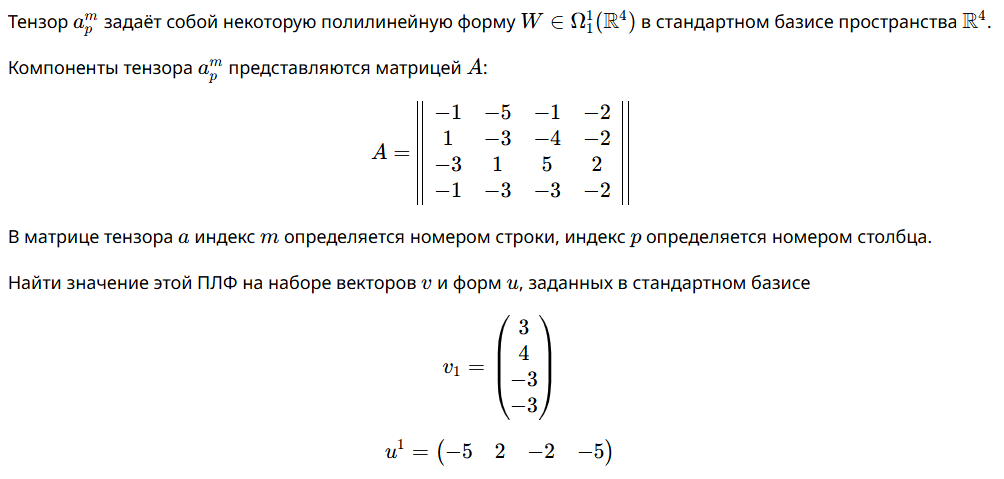

In [7]:
A = Tensor('−1 1 −3 −1 ​ −5 −3 1 −3 ​ −1 −4 5 −3 ​ −2 −2 2 −2 ​ ​', 4, 1, 1)
# print(A)
v = (3, 4, -3, -3)
u = (-5, 2, -2, -5)
s = 0
for m in range(4):
    for p in range(4):
        s += A[m][p] * v[p] * u[m]
print(s)

140


### Задача 6

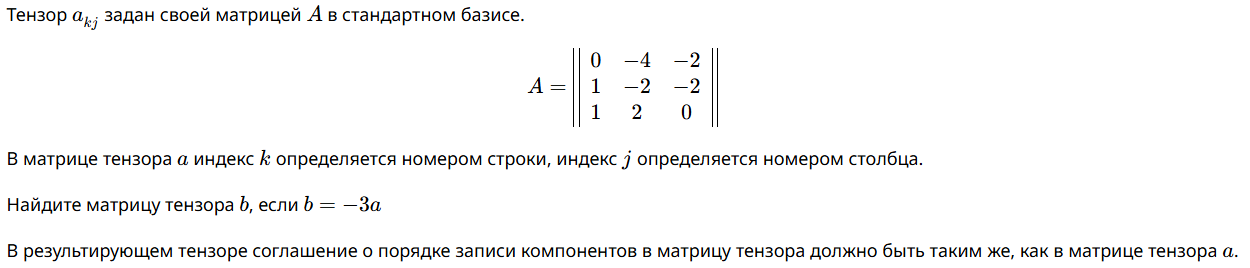

In [8]:
A = Tensor('0 1 1 ​ −4 −2 2 ​ −2 −2 0 ​ ​', 3, 0, 2)
# print(A)
B = A * -3
print(B)

Tensor (2, 0), dim = 3, status = TStatus.EVEN
0 12 6
-3 6 6
-3 -6 0
[0, 12, 6; -3, 6, 6; -3, -6, 0]


### Задача 7

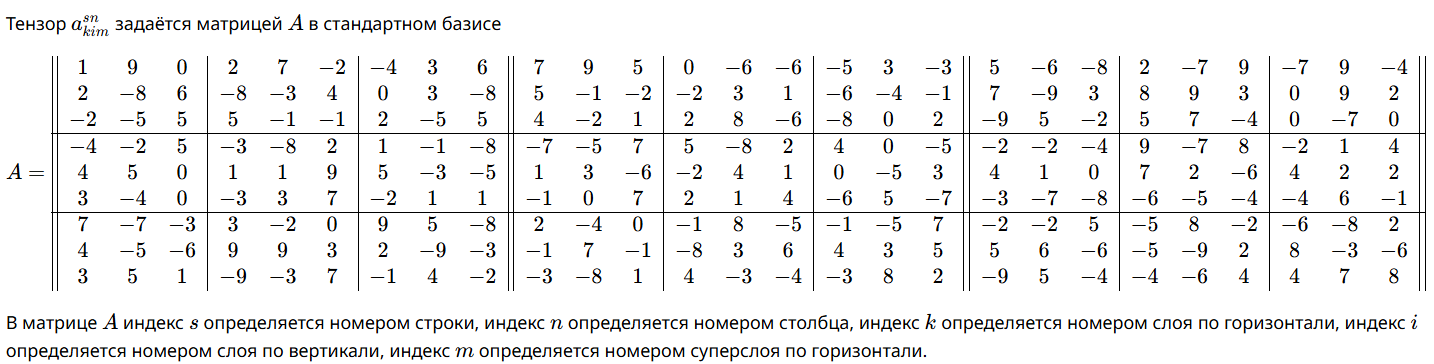

**Местами не перепутай**: ко=ЛФ, контра=обычные

### Задача 8

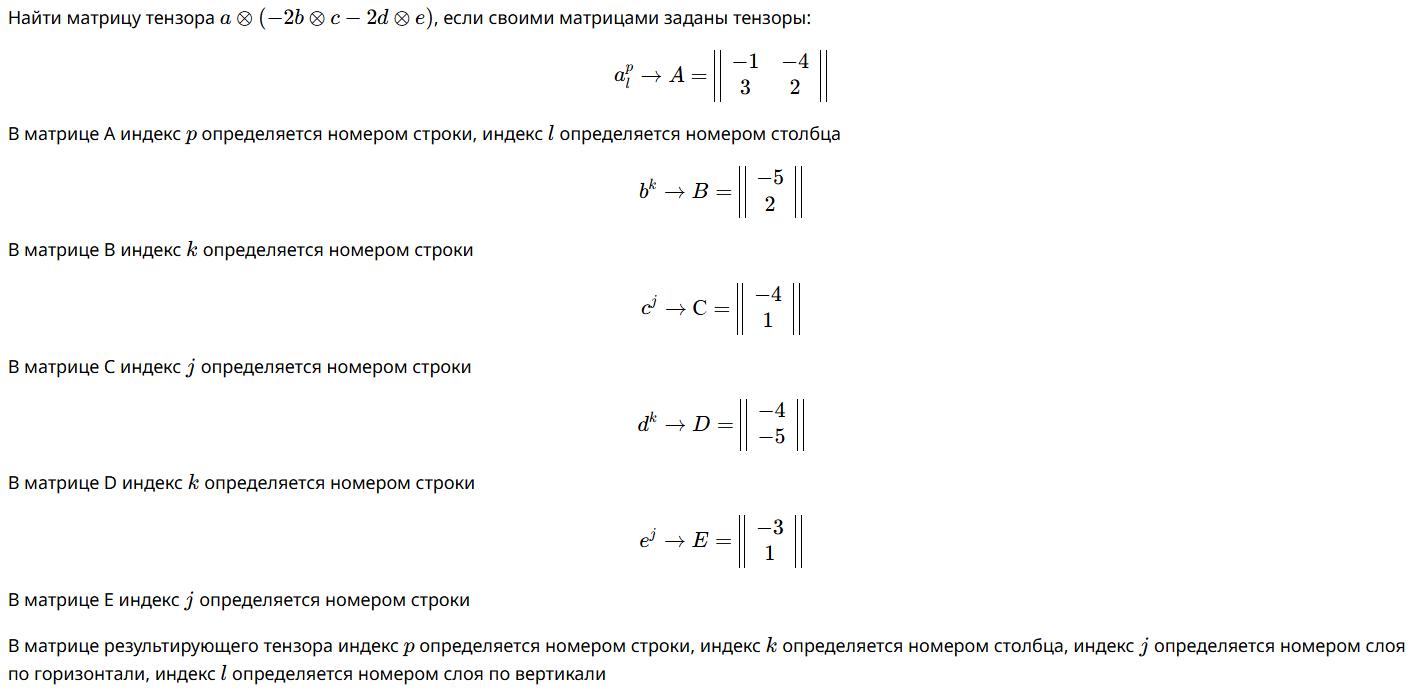

In [9]:
# a ⊗ ( − 2 b ⊗ c − 2 d ⊗ e )
A = Tensor('−1 3 ​ −4 2', 2, 1, 1)
B = Tensor('-5 2', 2, 1, 0)
C = Tensor('-4 1', 2, 1, 0)
D = Tensor('-4 -5', 2, 1, 0)
E = Tensor('-3 1', 2, 1, 0)
# print(A, B, C, D, E, sep='\n===\n')

R = A @ (((B * -2) @ C) + ((D * -2) @ E))

print(R.format)

[64, 14, -18, -6; -192, -42, 54, 18; 256, 56, -72, -24; -128, -28, 36, 12]


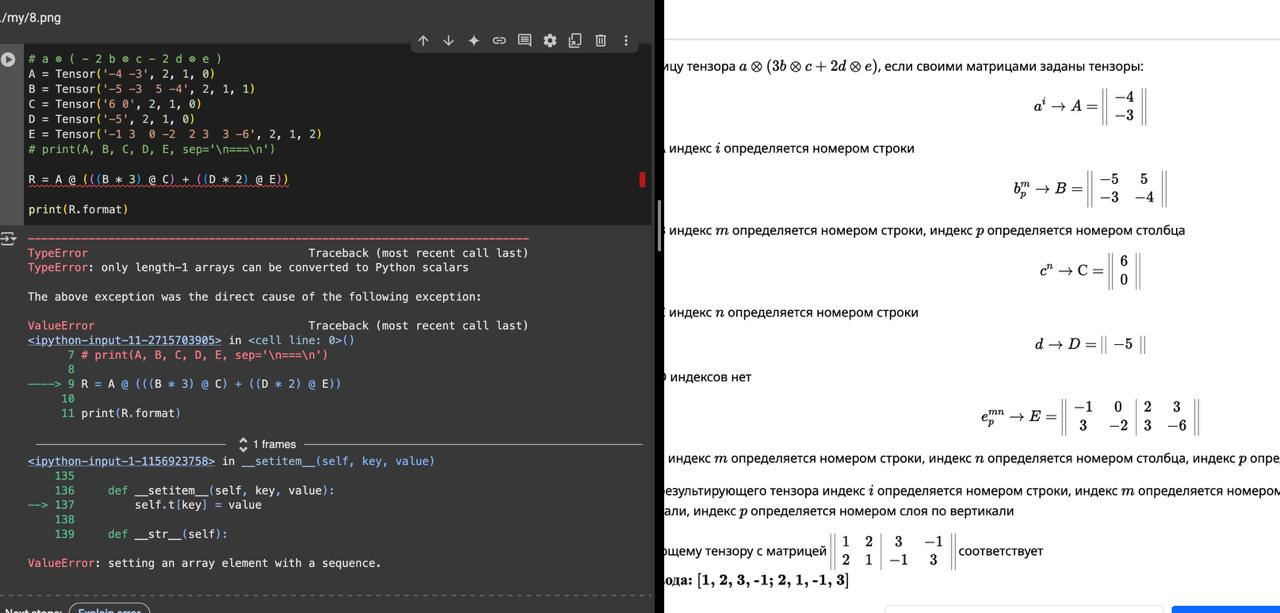

In [14]:
A = Tensor('-4 -3', 2, 1, 0)
B = Tensor('-5 -3 5 -4', 2, 1, 1)
C = Tensor('6 0', 2, 1, 0)
E = Tensor('-1 3 0 -2 2 3 3 -6', 2, 2, 1)
print(A, B, C, E, sep='\n===\n')

R = A @ (((B * 3) @ C) + (E * (-5 * 2)))
print(R.format)

Tensor (0, 1), dim = 2, status = TStatus.VERTICAL
-4
-3
[-4; -3]
===
Tensor (1, 1), dim = 2, status = TStatus.EVEN
-5 5
-3 -4
[-5, 5; -3, -4]
===
Tensor (0, 1), dim = 2, status = TStatus.VERTICAL
6
0
[6; 0]
===
Tensor (1, 2), dim = 2, status = TStatus.HORIZONTAL
-1 0 | 2 3
3 -2 | 3 -6
[-1, 0, 2, 3; 3, -2, 3, -6]
[320, 336, 0, -80; 240, 252, 0, -60; -280, 408, 120, -240; -210, 306, 90, -180]


### Задача 9

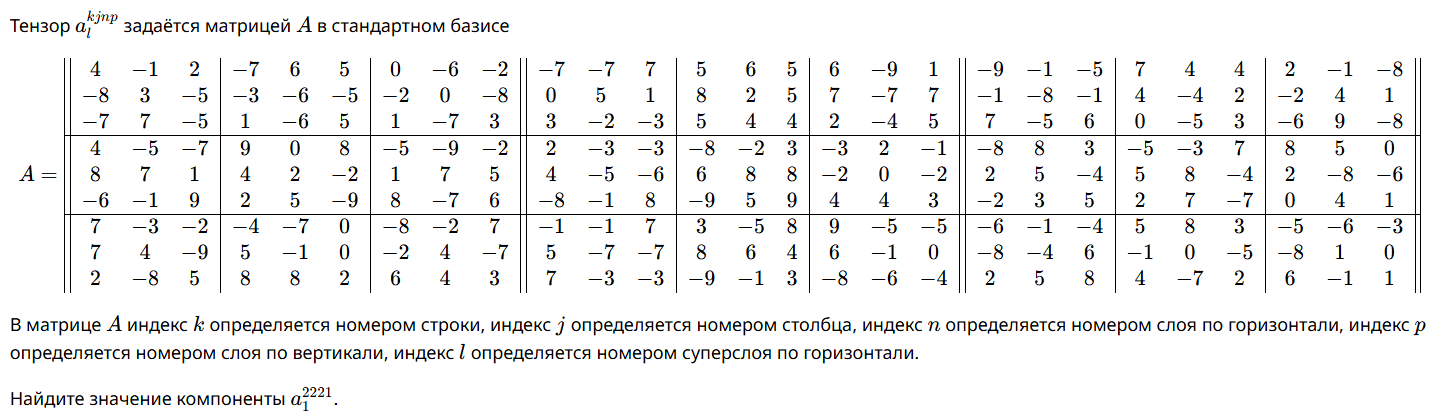

"Морской бой" - главное не перепутать суперстроки и суперстолбцы местами =)

In [ ]:
data = '''
4 −8 −7 4 8 −6 7 7 2 ​ −1 3 7 −5 7 −1 −3 4 −8 ​ 2 −5 −5 −7 1 9 −2 −9 5 ​ −7 −3 1 9 4 2 −4 5 8 ​ 6 −6 −6 0 2 5 −7 −1 8 ​ 5 −5 5 8 −2 −9 0 0 2 ​ 0 −2 1 −5 1 8 −8 −2 6 ​ −6 0 −7 −9 7 −7 −2 4 4 ​ −2 −8 3 −2 5 6 7 −7 3 ​ −7 0 3 2 4 −8 −1 5 7 ​ −7 5 −2 −3 −5 −1 −1 −7 −3 ​ 7 1 −3 −3 −6 8 7 −7 −3 ​ 5 8 5 −8 6 −9 3 8 −9 ​ 6 2 4 −2 8 5 −5 6 −1 ​ 5 5 4 3 8 9 8 4 3 ​ 6 7 2 −3 −2 4 9 6 −8 ​ −9 −7 −4 2 0 4 −5 −1 −6 ​ 1 7 5 −1 −2 3 −5 0 −4 ​ −9 −1 7 −8 2 −2 −6 −8 2 ​ −1 −8 −5 8 5 3 −1 −4 5 ​ −5 −1 6 3 −4 5 −4 6 8 ​ 7 4 0 −5 5 2 5 −1 4 ​ 4 −4 −5 −3 8 7 8 0 −7 ​ 4 2 3 7 −4 −7 3 −5 2 ​ 2 −2 −6 8 2 0 −5 −8 6 ​ −1 4 9 5 −8 4 −6 1 −1 ​ −8 1 −8 0 −6 1 −3 0 1 ​ ​ ​
'''
A = Tensor(data, 3, 4, 1)
# print(A)
k, j, n, p, l = 2, 2, 2, 1, 1
print(A[k - 1][j - 1][p - 1][n - 1][l - 1])

-6


### Задача 10
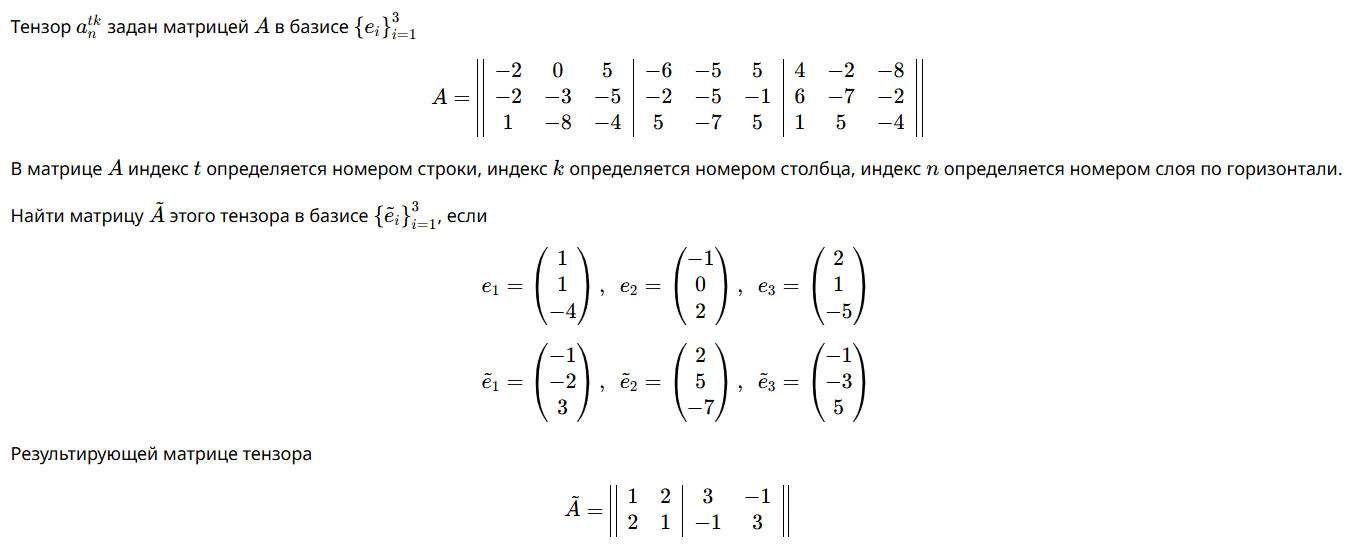

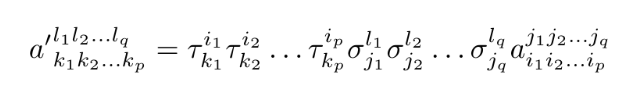

Для моего случая немая сумма будет такая
$\tilde{a}^{tk}_{n} = \tau^{i_1}_n * \sigma^t_{j_1} * \sigma^k_{j_2} * a^{j_1 j_2}_{i_1}$

In [ ]:
data = "−2 −2 1 ​ 0 −3 −8 ​ 5 −5 −4 ​ −6 −2 5 ​ −5 −5 −7 ​ 5 −1 5 ​ 4 6 1 ​ −2 −7 5 ​ −8 −2 −4 ​ ​​"
a = Tensor(data, 3, 2, 1)
print(a)

e1, e2, e3 = [1, 1, -4], [-1, 0, 2], [2, 1, -5]
old_basis = np.matrix([[e1[0], e2[0], e3[0]], [e1[1], e2[1], e3[1]], [e1[2], e2[2], e3[2]]], float)
e1, e2, e3 = [-1, -2, 3], [2, 5, -7], [-1, -3, 5]
new_basis = np.matrix([[e1[0], e2[0], e3[0]], [e1[1], e2[1], e3[1]], [e1[2], e2[2], e3[2]]], float)
# print(old_basis, new_basis, sep='\n')

S = np.linalg.inv(new_basis).dot(old_basis)
T = np.around(np.linalg.inv(S), 12)
T, S = np.asarray(T), np.asarray(S)
print(T, S, sep='\n')

tilde_a = np.zeros((3, 3, 3))
for (t, k, n) in it.product(range(3), repeat=3):
    total = 0
    for (i1, j1, j2) in it.product(range(3), repeat=3):
            total += T[i1, n] * S[t, j1] * S[k, j2] * a[j1, j2, i1]
    tilde_a[t, k, n] = total

tilde_a = np.round(tilde_a, 10).astype(int)
res_tensor = Tensor(tilde_a, 3, 2, 1)
print(res_tensor)

Tensor (1, 2), dim = 3, status = TStatus.HORIZONTAL
-2 0 5 | -6 -5 5 | 4 -2 -8
-2 -3 -5 | -2 -5 -1 | 6 -7 -2
1 -8 -4 | 5 -7 5 | 1 5 -4
[-2, 0, 5, -6, -5, 5, 4, -2, -8; -2, -3, -5, -2, -5, -1, 6, -7, -2; 1, -8, -4, 5, -7, 5, 1, 5, -4]
[[ 1. -2.  0.]
 [-4. 10. -5.]
 [-3.  7. -3.]]
[[ -5.   6. -10.]
 [ -3.   3.  -5.]
 [ -2.   1.  -2.]]
Tensor (1, 2), dim = 3, status = TStatus.HORIZONTAL
-1252 -675 -358 | 4022 2138 1068 | -3194 -1668 -765
-634 -339 -173 | 2053 1083 522 | -1650 -856 -381
-314 -163 -70 | 998 513 213 | -786 -399 -158
[-1252, -675, -358, 4022, 2138, 1068, -3194, -1668, -765; -634, -339, -173, 2053, 1083, 522, -1650, -856, -381; -314, -163, -70, 998, 513, 213, -786, -399, -158]
